# Task 2: Predict Future Stock Prices (Short-Term)

**Objective:** Use historical stock data to predict the next day's closing price.

**Stock:** Apple (AAPL) via Yahoo Finance (`yfinance`)

**Models:** Linear Regression, Random Forest Regressor

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style='whitegrid')

## 1. Load Historical Stock Data

In [2]:
TICKER = 'AAPL'
START_DATE = '2020-01-01'
END_DATE = '2024-12-31'

stock = yf.Ticker(TICKER)
df = stock.history(start=START_DATE, end=END_DATE)
df = df.reset_index()
print('Shape:', df.shape)
df.head()

Shape: (1257, 8)


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2020-01-02 00:00:00-05:00,71.344054,72.394086,71.091184,72.333878,135480400,0.0,0.0
1,2020-01-03 00:00:00-05:00,71.563198,72.389250,71.406659,71.630630,146322800,0.0,0.0
2,2020-01-06 00:00:00-05:00,70.754028,72.239958,70.503561,72.201424,118387200,0.0,0.0
3,2020-01-07 00:00:00-05:00,72.211064,72.466345,71.642704,71.861862,108872000,0.0,0.0
4,2020-01-08 00:00:00-05:00,71.565636,73.318893,71.565636,73.017853,132079200,0.0,0.0


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1257 entries, 0 to 1256
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype                          
---  ------        --------------  -----                          
 0   Date          1257 non-null   datetime64[s, America/New_York]
 1   Open          1257 non-null   float64                        
 2   High          1257 non-null   float64                        
 3   Low           1257 non-null   float64                        
 4   Close         1257 non-null   float64                        
 5   Volume        1257 non-null   int64                          
 6   Dividends     1257 non-null   float64                        
 7   Stock Splits  1257 non-null   float64                        
dtypes: datetime64[s, America/New_York](1), float64(6), int64(1)
memory usage: 78.7 KB


,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,1257.000000,1257.000000,1257.000000,1257.000000,1.257000e+03,1257.000000,1257.000000
mean,151.144223,152.820988,149.602776,151.300259,9.061168e+07,0.003598,0.003182
std,41.717783,41.916450,41.553582,41.778189,5.324605e+07,0.028385,0.112822
min,55.059305,55.160694,51.324793,54.163696,2.323470e+07,0.000000,0.000000
25%,125.724384,127.334355,124.234801,126.249901,5.546960e+07,0.000000,0.000000
50%,149.768118,151.690633,147.948384,149.942215,7.629970e+07,0.000000,0.000000
75%,175.593390,177.445048,174.316238,175.746490,1.077601e+08,0.000000,0.000000
max,256.550893,258.448771,255.994450,257.375610,4.265100e+08,0.250000,4.000000


## 2. Feature Engineering

Use Open, High, Low, Volume (and lagged Close) to predict **next day's Close**.

In [4]:
data = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

# Target: next day's closing price
data['Target_Close'] = data['Close'].shift(-1)

# Lag features for temporal context
for lag in [1, 2, 3]:
    data[f'Close_lag_{lag}'] = data['Close'].shift(lag)
    data[f'Volume_lag_{lag}'] = data['Volume'].shift(lag)

data = data.dropna()
print('Shape after feature engineering:', data.shape)
data.head()

Shape after feature engineering: (1253, 12)


,Open,High,Low,Close,Volume,Target_Close,Close_lag_1,Volume_lag_1,Close_lag_2,Volume_lag_2,Close_lag_3,Volume_lag_3
3,72.211064,72.466345,71.642704,71.861862,108872000,73.017853,72.201424,118387200.0,71.630630,146322800.0,72.333878,135480400.0
4,71.565636,73.318893,71.565636,73.017853,132079200,74.568810,71.861862,108872000.0,72.201424,118387200.0,71.630630,146322800.0
5,73.993218,74.761472,73.742758,74.568810,170108400,74.737358,73.017853,132079200.0,71.861862,108872000.0,72.201424,118387200.0
6,74.802387,75.300911,74.236431,74.737358,140644800,76.334084,74.568810,170108400.0,73.017853,132079200.0,71.861862,108872000.0
7,75.052863,76.360579,74.934851,76.334084,121532000,75.303345,74.737358,140644800.0,74.568810,170108400.0,73.017853,132079200.0


## 3. Train/Test Split

In [5]:
feature_cols = [c for c in data.columns if c not in ['Target_Close', 'Close']]
X = data[feature_cols]
y = data['Target_Close']

# Time-series split: first 80% train, last 20% test
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train: {len(X_train)}, Test: {len(X_test)}')

Train: 1002, Test: 251


## 4. Model Training

In [6]:
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f'{name} — RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.4f}')
    return y_pred

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = evaluate_model('Linear Regression', y_test, lr.predict(X_test))

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = evaluate_model('Random Forest', y_test, rf.predict(X_test))

Linear Regression — RMSE: 53.23, MAE: 47.06, R²: -3.3897


Random Forest — RMSE: 26.19, MAE: 19.39, R²: -0.0626


## 5. Actual vs Predicted — Visualization

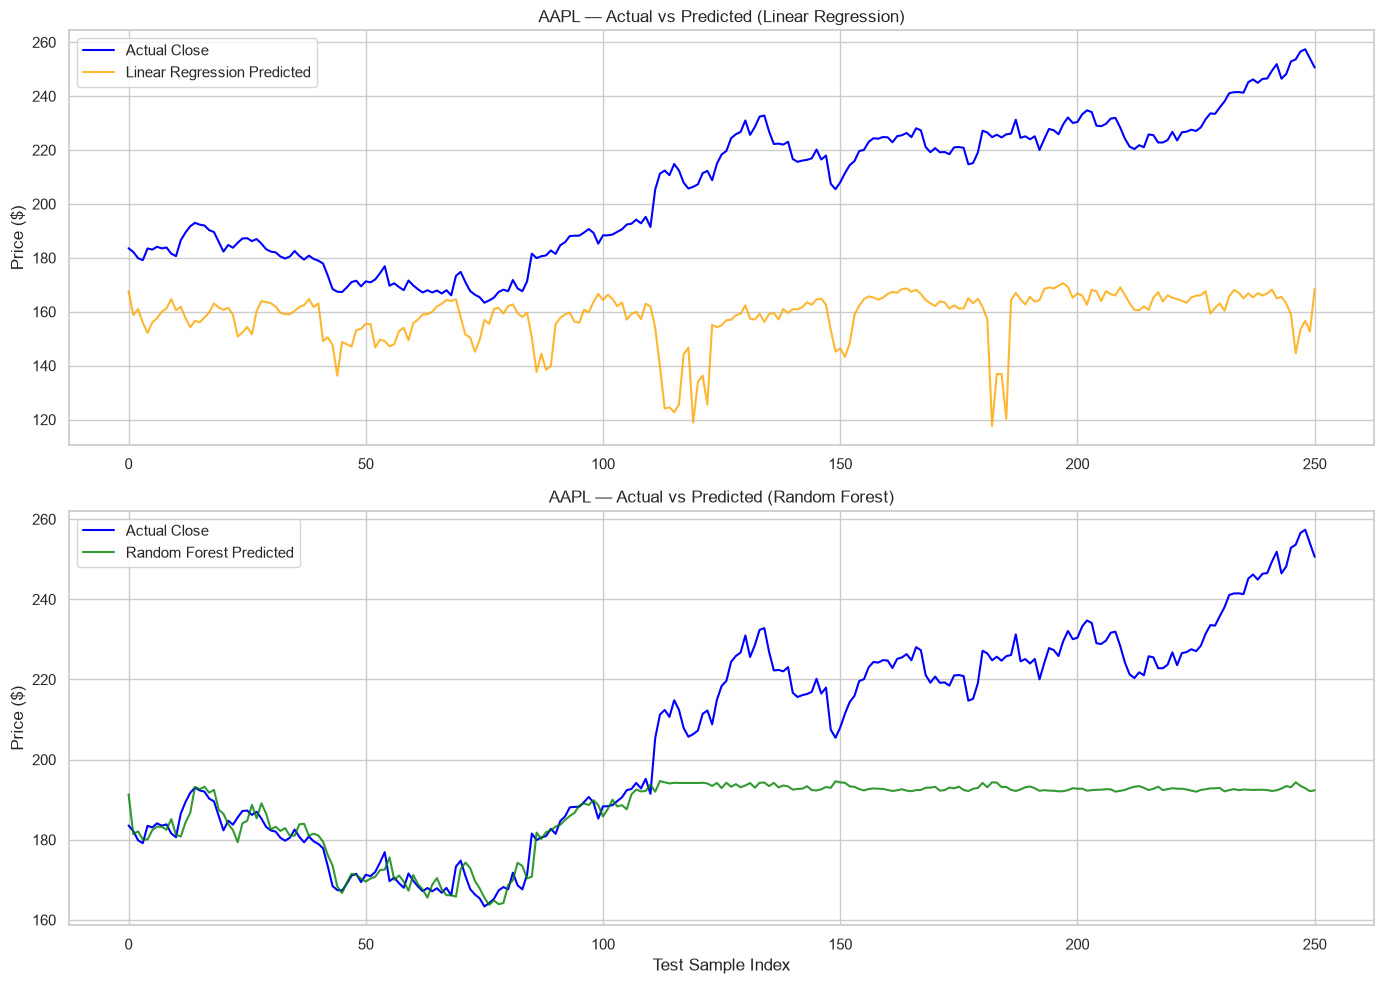

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(y_test.values, label='Actual Close', color='blue', linewidth=1.5)
axes[0].plot(lr_pred, label='Linear Regression Predicted', color='orange', alpha=0.8)
axes[0].set_title(f'{TICKER} — Actual vs Predicted (Linear Regression)')
axes[0].legend()
axes[0].set_ylabel('Price ($)')

axes[1].plot(y_test.values, label='Actual Close', color='blue', linewidth=1.5)
axes[1].plot(rf_pred, label='Random Forest Predicted', color='green', alpha=0.8)
axes[1].set_title(f'{TICKER} — Actual vs Predicted (Random Forest)')
axes[1].legend()
axes[1].set_ylabel('Price ($)')
axes[1].set_xlabel('Test Sample Index')

plt.tight_layout()
plt.show()

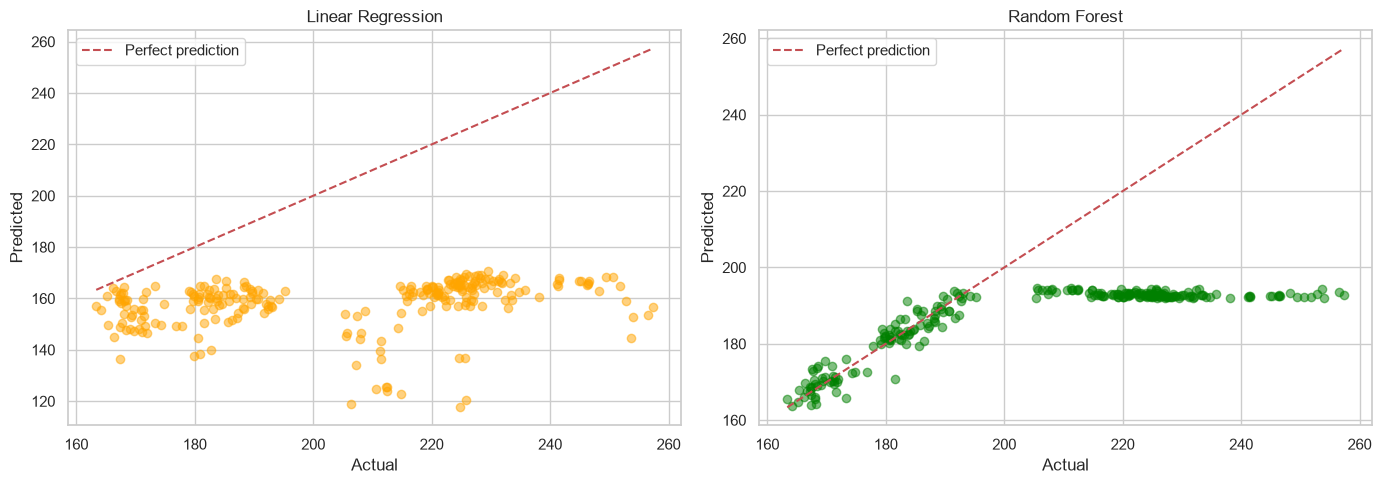

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, lr_pred, alpha=0.5, color='orange')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Linear Regression')
axes[0].legend()

axes[1].scatter(y_test, rf_pred, alpha=0.5, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect prediction')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Random Forest')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Results and Insights

- **Features used:** Open, High, Low, Volume, and lagged Close/Volume values.
- **Target:** Next trading day's closing price.
- Random Forest often captures non-linear market patterns better than Linear Regression.
- Short-term stock prediction is inherently noisy; models work best in stable trends.
- **Disclaimer:** This is for educational purposes only, not financial advice.